## Determining the phase shifts for scattering in a Lennard-Jones potential

In this notebook we'll study the scattering states in a Lennard-Jones potential:

$$
V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^12 - \left(\frac{\sigma}{r}\right)^6\right]
$$ù

In [1]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt

$$\frac{\hbar^2}{2\mu} = 0.0249 \quad meV A^2$$
$$\sigma = 2 \quad A$$

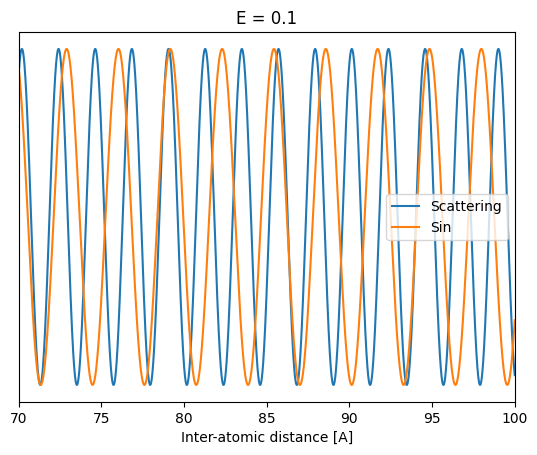

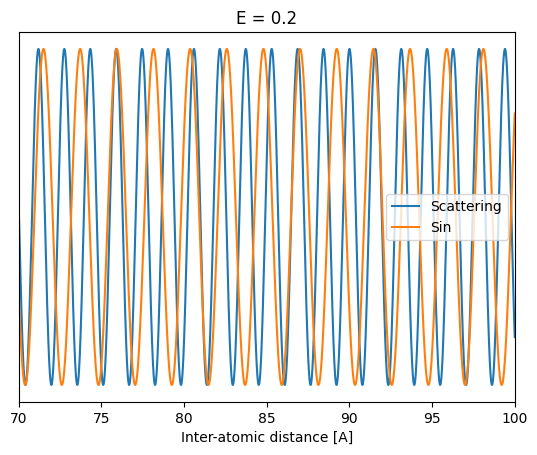

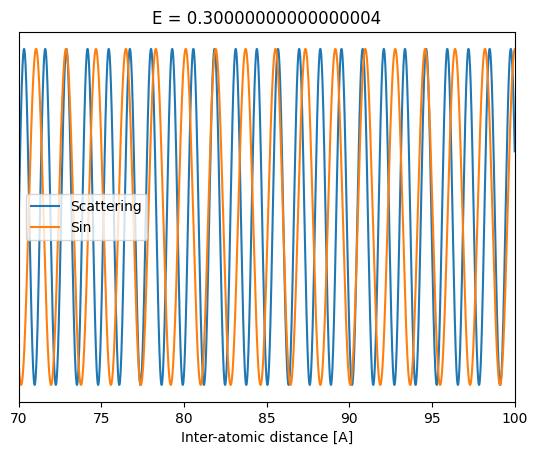

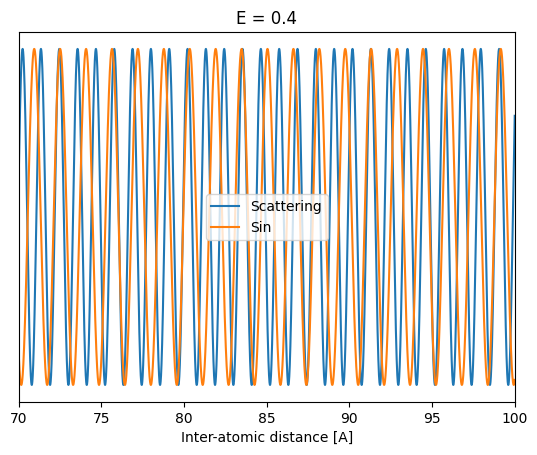

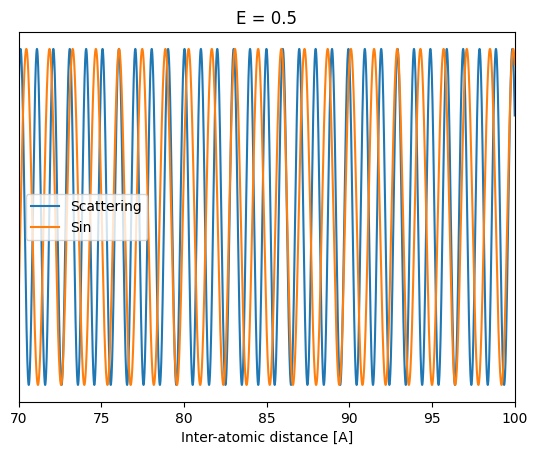

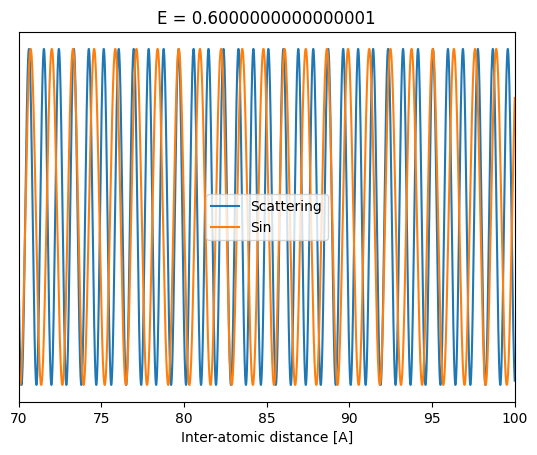

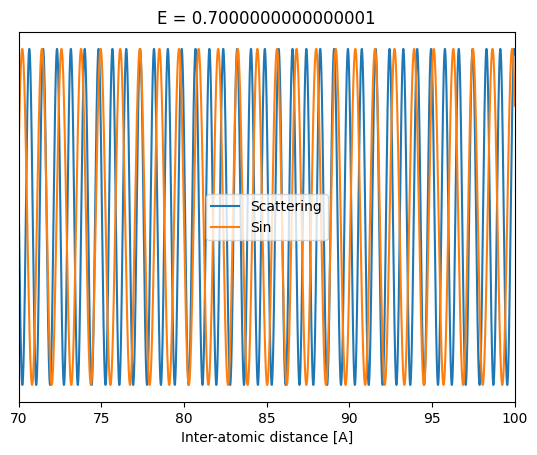

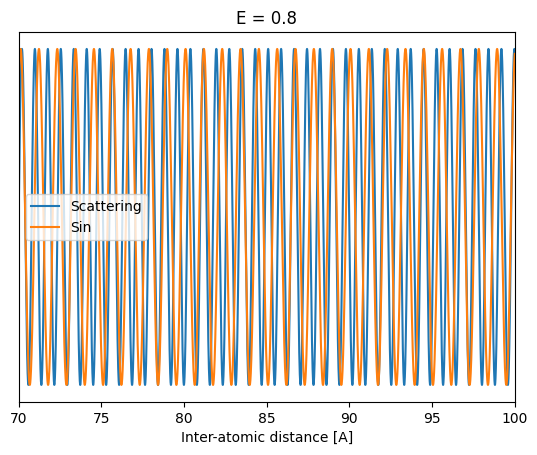

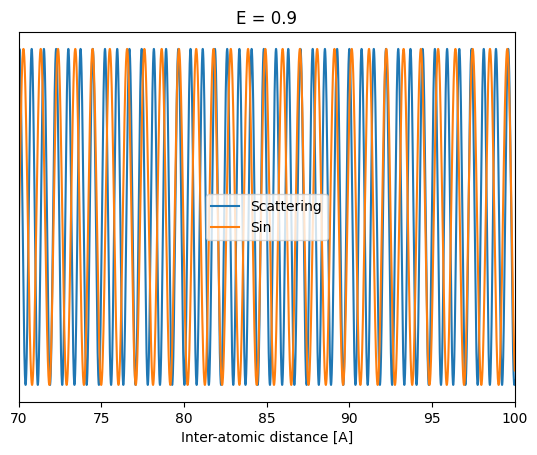

In [3]:
h = 1e-3
r_max = 100
sigma = 2
E = np.arange(0.1, 1, .1)
kwargs = {'k' : .0249, 'sigma' : sigma, 'epsilon' : 5.99}

grid = phys.potentials.helper_grid_lj(h, r_max, sigma = 2)
solver = phys.numerics.SolverOpts()

ls = np.arange(0, 1, 1)

for l in ls:
    coord, psi = phys.scattering.integrate_scattering_state(E, l, phys.potentials.lennard_jones, grid = grid, solver = solver, **kwargs)
    for _psi, _E in zip(psi, E):
        _psi = phys.scattering.normalize_lj_scattering_state(coord, _psi, sigma = sigma, n = 5)
        plt.title(f'E = {_E}')
        plt.plot(coord, np.ravel(_psi), label = 'Scattering')
        plt.plot(coord, np.sin(phys.wave_vector(_E, **kwargs)*coord), label = "Sin")
        plt.legend()
        plt.yticks(ticks = [])
        plt.xlim([70, 100])
        plt.xlabel('Inter-atomic distance [A]')
        plt.show()


In [ ]:
h = 1e-2
r_max = 100
ls = np.arange(0, 1, 1)
E = np.linspace(0.1, 1, 50)
kwargs = {'hbar_squared_over_2_m' : 2.1, 'sigma' : 2, 'epsilon' : 5.99}

grid = phys.potentials.helper_grid_lj(h, r_max, sigma = 2)
solver = phys.numerics.SolverOpts()

phases = []


for _l in ls:
    coord, psi = phys.integrate_scattering_state(E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = 70000, **kwargs)
    print(f'Integration completed for l = {_l}.')
    for _psi, _E in zip(psi, E):
        mean_phase, std_phase = phys.compute_phase_shift(_psi, coord, _E, _l, **kwargs)
        print(f'ps = {mean_phase:.3f} with std dev = {std_phase:.3f}')
        phases.append(mean_phase)
    

Integration completed for l = 0.
ps = -1.312 with std dev = 0.235
ps = -1.327 with std dev = 0.222
ps = -1.398 with std dev = 0.216
ps = -1.464 with std dev = 0.211
ps = -1.480 with std dev = 0.194
ps = -1.538 with std dev = 0.190
ps = 1.549 with std dev = 0.186
ps = 1.497 with std dev = 0.183
ps = 1.448 with std dev = 0.180
ps = 1.432 with std dev = 0.165
ps = 1.387 with std dev = 0.162
ps = 1.344 with std dev = 0.160
ps = 1.303 with std dev = 0.158
ps = 1.263 with std dev = 0.155
ps = 1.230 with std dev = 0.148
ps = 1.209 with std dev = 0.141
ps = 1.173 with std dev = 0.139
ps = 1.138 with std dev = 0.138
ps = 1.104 with std dev = 0.136
ps = 1.071 with std dev = 0.135
ps = 1.039 with std dev = 0.134
ps = 1.012 with std dev = 0.128
ps = 0.994 with std dev = 0.122
ps = 0.964 with std dev = 0.121
ps = 0.935 with std dev = 0.120
ps = 0.907 with std dev = 0.118
ps = 0.879 with std dev = 0.118
ps = 0.852 with std dev = 0.117
ps = 0.830 with std dev = 0.111
ps = 0.804 with std dev = 0.110
p

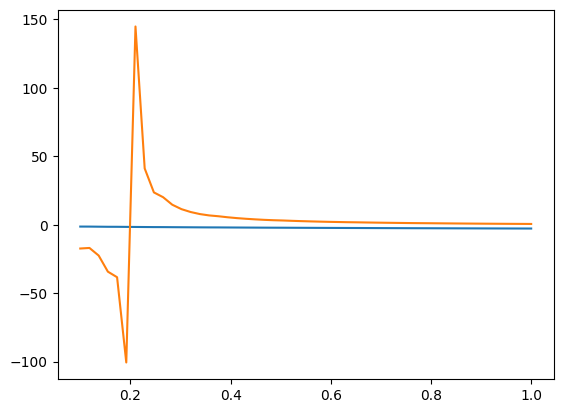

In [5]:
phases = np.unwrap(phases, period=np.pi)

plt.plot(E, phases)
plt.plot(E, np.tan(phases) / phys.wave_vector(E, **kwargs))

In [8]:
phases

array([-0.99316451, -1.36907012, -1.63842254, -1.85318949, -2.03385824,
       -2.19094908, -2.33059283, -2.45675338, -2.57228076])

In [3]:
h = 1e-3
r_max = 100
sigma = 2

l_vals = np.arange(0, 7, 1)   # l = 0,...,6
E_vals = np.linspace(0.1, 3.5, 10)

kwargs = {'k': 2.1, 'sigma': sigma, 'epsilon': 5.99}

grid = phys.potentials.helper_grid_lj(h, r_max, sigma=sigma)
solver = phys.numerics.SolverOpts()

coord, psi = phys.scattering.integrate_scattering_state(
    0.1, 0,
    phys.potentials.lennard_jones,
    grid=grid,
    solver=solver,
    store_wavefunction=False,
    n_points = 70000,
    **kwargs
)


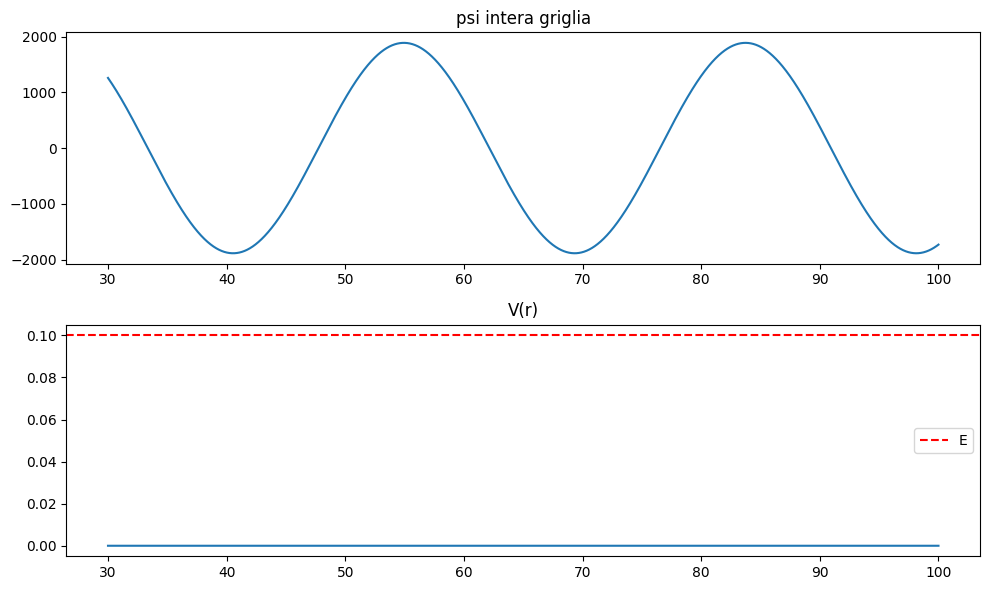

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(coord, np.ravel(psi))
ax1.set_title("psi intera griglia")
ax2.plot(coord, phys.lennard_jones(coord, **kwargs))  # il tuo potenziale
ax2.set_title("V(r)")
ax2.axhline(0.1, color='r', linestyle='--', label='E')
ax2.legend()
plt.tight_layout()
plt.show()

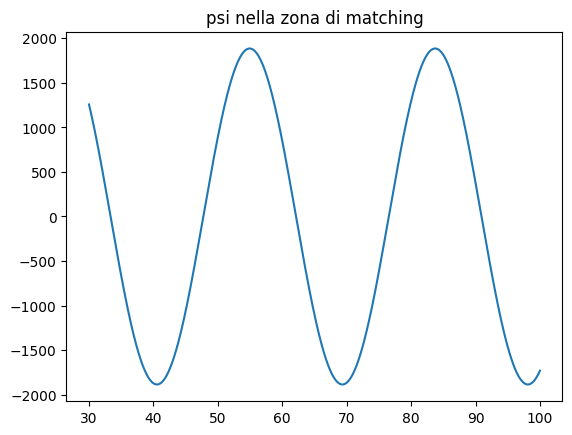

std/mean dell'ampiezza: 0.4914


In [5]:
plt.plot(coord, np.ravel(psi))
plt.title("psi nella zona di matching")
plt.show()

# Se l'ampiezza non è costante qui, sei ancora dentro il potenziale
amplitude_check = np.abs(np.ravel(psi))
print(f"std/mean dell'ampiezza: {amplitude_check.std()/amplitude_check.mean():.4f}")
# Vuoi questo < 0.01

In [6]:
psi = np.ravel(psi)
dr = coord[1] - coord[0]

# Misura il periodo empirico direttamente
psi_asym = psi
from scipy.signal import find_peaks
peaks, _ = find_peaks(psi_asym)
period_idx = int(round(np.mean(np.diff(peaks))))
print(f"Periodo empirico: {period_idx} punti = {period_idx * dr:.4f} Å")

# Usa esattamente mezzo periodo — massimizza la sensibilità del cross-ratio
delta_index = period_idx // 2
print(f"delta_index ottimale: {delta_index}")

Periodo empirico: 28793 punti = 28.7930 Å
delta_index ottimale: 14396


Periodo empirico: 28793 punti = 28.7930 Å
Cicli nella zona asintotica: 2
amp_tol_abs: 63.82  (mediana psi: 1276.35)


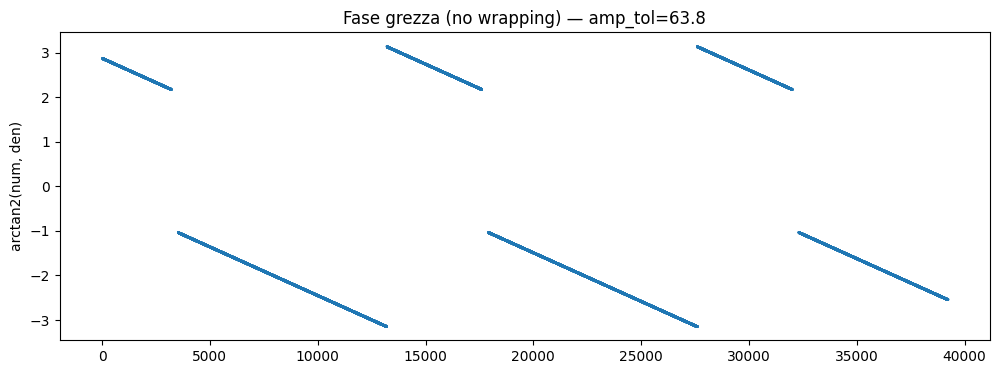


Picchi trovati per stime: 2
  r1=54.94 Å, r2=62.14 Å → δ = -0.993166 rad
  r1=83.73 Å, r2=90.93 Å → δ = -0.993163 rad

Stime sui picchi: 2
Mean phase shift: -0.993165 rad
Std:              0.000002 rad


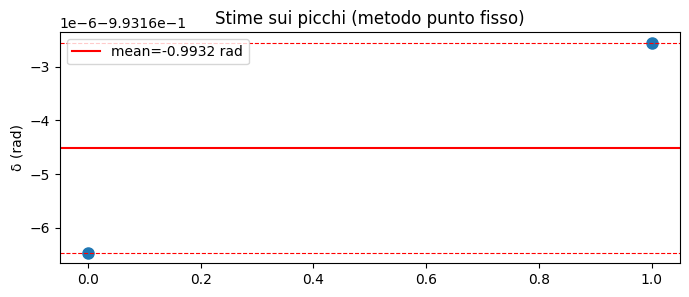

In [21]:
import scipy as sp
from scipy.signal import find_peaks

psi = np.ravel(psi)
l = 0

k = phys.wave_vector(0.1, k=2.1)

# Zona asintotica
i_asym_start = np.searchsorted(coord, 30.0)
i_asym_end   = np.searchsorted(coord, 98.0)
coord_a = coord[i_asym_start:i_asym_end]
psi_a   = psi[i_asym_start:i_asym_end]

# Periodo empirico calcolato sulla zona asintotica
peaks_all, _ = find_peaks(psi_a)
period_idx = int(round(np.mean(np.diff(peaks_all))))
print(f"Periodo empirico: {period_idx} punti = {period_idx * (coord[1]-coord[0]):.4f} Å")
print(f"Cicli nella zona asintotica: {len(peaks_all)}")

# Soglia relativa calcolata sulla mediana della zona asintotica (robusta agli outlier)
amp_tol_abs = 0.05 * np.median(np.abs(psi_a))
print(f"amp_tol_abs: {amp_tol_abs:.2f}  (mediana psi: {np.median(np.abs(psi_a)):.2f})")

# --- Finestra scorrevole (diagnostica) ---
delta_index = period_idx
raw_atan2 = []
for i in range(len(coord_a) - delta_index):
    r1, r2 = coord_a[i], coord_a[i + delta_index]
    u1, u2 = psi_a[i],   psi_a[i + delta_index]
    if abs(u1) < amp_tol_abs or abs(u2) < amp_tol_abs:
        raw_atan2.append(np.nan)
        continue
    w1, w2 = u1 * r1, u2 * r2
    j1 = sp.special.spherical_jn(l, k * r1)
    j2 = sp.special.spherical_jn(l, k * r2)
    y1 = sp.special.spherical_yn(l, k * r1)
    y2 = sp.special.spherical_yn(l, k * r2)
    num = j1 * w2 - j2 * w1
    den = y1 * w2 - y2 * w1
    raw_atan2.append(np.arctan2(num, den))

raw_atan2 = np.array(raw_atan2)

plt.figure(figsize=(12, 4))
plt.plot(raw_atan2, '.', markersize=1)
plt.title(f"Fase grezza (no wrapping) — amp_tol={amp_tol_abs:.1f}")
plt.ylabel("arctan2(num, den)")
plt.show()

# --- Metodo a punto fisso sui picchi ---
# Cerca picchi in zona più conservativa: r = 50..95 Å
i_peak_start = np.searchsorted(coord, 50.0) - i_asym_start
i_peak_end   = np.searchsorted(coord, 95.0) - i_asym_start
peaks_asym, _ = find_peaks(psi_a[i_peak_start:i_peak_end])
peaks_asym += i_peak_start
print(f"\nPicchi trovati per stime: {len(peaks_asym)}")

estimates = []
for ip in peaks_asym:
    i2 = ip + period_idx // 4
    if i2 >= len(coord_a):
        continue
    u1, u2 = psi_a[ip], psi_a[i2]
    """
    if abs(u1) < amp_tol_abs or abs(u2) < amp_tol_abs:
        continue
    """
    r1, r2 = coord_a[ip], coord_a[i2]
    w1, w2 = u1 * r1, u2 * r2
    j1 = sp.special.spherical_jn(l, k * r1)
    j2 = sp.special.spherical_jn(l, k * r2)
    y1 = sp.special.spherical_yn(l, k * r1)
    y2 = sp.special.spherical_yn(l, k * r2)
    num = j1 * w2 - j2 * w1
    den = y1 * w2 - y2 * w1
    estimates.append(np.arctan2(num, den))
    print(f"  r1={r1:.2f} Å, r2={r2:.2f} Å → δ = {np.arctan2(num,den):.6f} rad")

if len(estimates) == 0:
    print("Nessuna stima valida — prova ad abbassare amp_tol_abs o allargare la zona.")
else:
    estimates = np.array(estimates)
    wrapped_est = 0.5 * np.angle(np.exp(2j * estimates))
    z = np.mean(np.exp(2j * wrapped_est))
    mean_phase = 0.5 * np.angle(z)
    residuals  = 0.5 * np.angle(np.exp(2j * (wrapped_est - mean_phase)))
    std_phase  = np.std(residuals)

    print(f"\nStime sui picchi: {len(estimates)}")
    print(f"Mean phase shift: {mean_phase:.6f} rad")
    print(f"Std:              {std_phase:.6f} rad")

    plt.figure(figsize=(8, 3))
    plt.plot(wrapped_est, 'o', markersize=8)
    plt.axhline(mean_phase, color='r', label=f'mean={mean_phase:.4f} rad')
    if len(estimates) > 1:
        plt.axhline(mean_phase + std_phase, color='r', linestyle='--', linewidth=0.8)
        plt.axhline(mean_phase - std_phase, color='r', linestyle='--', linewidth=0.8)
    plt.title("Stime sui picchi (metodo punto fisso)")
    plt.ylabel("δ (rad)")
    plt.legend()
    plt.show()

In [17]:
print(f"i_asym_start: {i_asym_start}, i_asym_end: {i_asym_end}")
print(f"Picchi trovati nella zona asintotica: {len(peaks_asym)}")
print(f"period_idx // 4 = {period_idx // 4}")
if len(peaks_asym) > 0:
    print(f"Primo picco: indice {peaks_asym[0]}, r = {coord_a[peaks_asym[0]]:.2f} Å")
    print(f"i2 del primo picco: {peaks_asym[0] + period_idx // 4}, len(coord_a): {len(coord_a)}")
print(f"amp_tol_abs: {amp_tol_abs:.2f}")
print(f"max(psi_a): {np.max(np.abs(psi_a)):.2f}")
print(f"psi al primo picco: {psi_a[peaks_asym[0]]:.2f}" if len(peaks_asym) > 0 else "nessun picco")

i_asym_start: 20001, i_asym_end: 65000
Picchi trovati nella zona asintotica: 2
period_idx // 4 = 7198
Primo picco: indice 24939, r = 54.94 Å
i2 del primo picco: 32137, len(coord_a): 70000
amp_tol_abs: 94.31
max(psi_a): 1886.14
psi al primo picco: 1886.14


In [18]:
i_asym_start = np.searchsorted(coord_a, 50.0)
i_asym_end   = np.searchsorted(coord_a, 95.0)

# Soglia relativa calcolata SOLO sulla zona asintotica
amp_asym = np.abs(psi_a[i_asym_start:i_asym_end])
amp_tol_abs = 0.05 * np.max(amp_asym)
print(f"max psi in zona asintotica: {np.max(amp_asym):.2f}")
print(f"amp_tol_abs corretto:       {amp_tol_abs:.2f}")

peaks_asym, _ = find_peaks(psi_a[i_asym_start:i_asym_end])
peaks_asym += i_asym_start
print(f"Picchi nella zona asintotica: {len(peaks_asym)}")

max psi in zona asintotica: 1886.14
amp_tol_abs corretto:       94.31
Picchi nella zona asintotica: 2


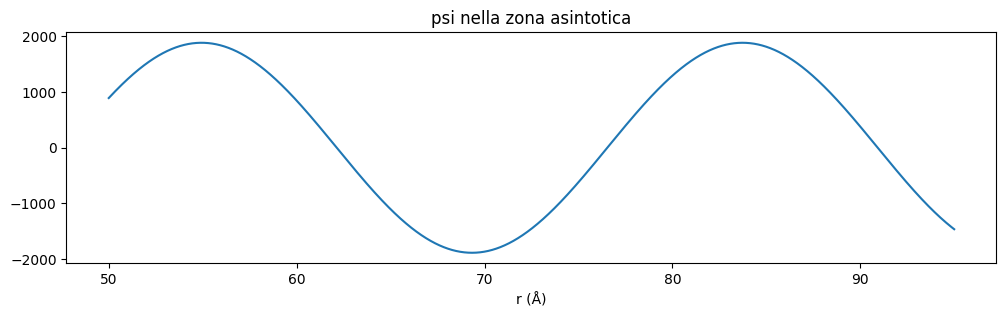

Massimo a r = 83.73 Å, valore = 1886.14
Ampiezza tipica (mediana): 1315.51


In [19]:
plt.figure(figsize=(12, 3))
plt.plot(coord_a[i_asym_start:i_asym_end], 
         psi_a[i_asym_start:i_asym_end])
plt.title("psi nella zona asintotica")
plt.xlabel("r (Å)")
plt.show()

# E stampa dove si trova il massimo
i_max = np.argmax(np.abs(psi_a[i_asym_start:i_asym_end])) + i_asym_start
print(f"Massimo a r = {coord_a[i_max]:.2f} Å, valore = {psi_a[i_max]:.2f}")
print(f"Ampiezza tipica (mediana): {np.median(np.abs(psi_a[i_asym_start:i_asym_end])):.2f}")

In [42]:
import scipy.constants as const

m_H  = 1.008 * const.u           # kg
m_Kr = 83.798 * const.u          # kg
mu   = m_H * m_Kr / (m_H + m_Kr) # kg

hbar2_over_2mu = const.hbar**2 / (2 * mu)  # J·m²

# Conversioni:
# J → meV: 1 J = 1/const.e * 1e3 meV
# m² → Å²: 1 m² = 1e20 Å²
J_to_meV = 1e3 / const.e          # 6.242e21 meV/J
m2_to_A2 = 1e20                   # Å²/m²

hbar2_over_2mu_meV_A2 = hbar2_over_2mu * J_to_meV * m2_to_A2
print(f"ℏ²/2µ = {hbar2_over_2mu_meV_A2:.6f} meV·Å²")

# Verifica con E=0.1 meV
k = (0.1 / hbar2_over_2mu_meV_A2) ** 0.5
print(f"k     = {k:.6f} Å⁻¹")
print(f"lambda = {2*const.pi/k:.4f} Å")

ℏ²/2µ = 2.098434 meV·Å²
k     = 0.218299 Å⁻¹
lambda = 28.7824 Å


In [12]:
from scipy.signal import find_peaks

k_calc = phys.wave_vector(0.1, k=2.1)

peaks, _ = find_peaks(psi_a)
period_A = np.mean(np.diff(peaks)) * (coord[1] - coord[0])
k_emp = 2 * np.pi / period_A

print(f"k calcolato:  {k_calc:.6f} Å⁻¹")
print(f"k empirico:   {k_emp:.6f} Å⁻¹")
print(f"rapporto k_emp/k_calc: {k_emp/k_calc:.6f}")
print(f"E usata:      {0.1:.6f} meV")
print(f"E empirica:   {k_emp**2 * 2.1:.6f} meV")

k calcolato:  0.218218 Å⁻¹
k empirico:   0.218219 Å⁻¹
rapporto k_emp/k_calc: 1.000006
E usata:      0.100000 meV
E empirica:   0.100001 meV


In [13]:
peaks, _ = find_peaks(psi_a)
period_idx = int(round(np.mean(np.diff(peaks))))
print(f"Periodo: {period_idx} punti")
print(f"delta_index ottimale: {period_idx // 2}")

Periodo: 28793 punti
delta_index ottimale: 14396


In [22]:
a = np.array([1, 2, 3, 4, 5])

In [23]:
a[:-2]

array([1, 2, 3])

In [24]:
a[:2]

array([1, 2])

In [25]:
a[2:]

array([3, 4, 5])

In [26]:
a[1:-1]

array([2, 3, 4])